# NB1 — Proposed Model Evaluation + Grad-CAM + Affinity Calibration

GPU time: ~10 min. Run FIRST. No training — loads Untitled7 checkpoint. Saves prop_eval.pth, cal_adj.npy, gradcam.png to Drive.

**Before running:** Connect T4 GPU (Runtime → Change runtime type → T4 GPU)

**Drive folder:** `MyDrive/CNN_GNN_Results/` must exist (created automatically on first run).

In [ ]:
import os, hashlib, random, warnings, json, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             f1_score, accuracy_score)
from scipy.stats import chi2
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

CLASS_NAMES  = ['Cardiomegaly','Covid-19','Normal',
                'Pneumonia','Pneumothorax','Tuberculosis']
NUM_CLASSES  = 6
DATASET_PATH = '/content/drive/MyDrive/Dataset'
RESULTS_DIR  = '/content/drive/MyDrive/CNN_GNN_Results'
CKPT_PATH    = f'{RESULTS_DIR}/cnn_gnn_final.pth'
BATCH_SIZE   = 32
IMAGE_SIZE   = 224
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup complete.')


Mounted at /content/drive
Device: cuda
Setup complete.


In [ ]:
# ── EXACT model from Untitled7.ipynb ─────────────────────────
class FeatureBasedGNN(nn.Module):
    def __init__(self, num_classes=6, feature_dim=256, hidden_dim=128):
        super().__init__()
        self.disease_prototypes = nn.Parameter(
            torch.randn(num_classes, hidden_dim) * 0.01)
        self.relation_matrix = nn.Parameter(
            torch.randn(num_classes, num_classes) * 0.01)
        self.image_projector = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(0.2))
        self._adj = None

    def forward(self, feat):
        img_feat   = self.image_projector(feat)
        sim        = torch.matmul(img_feat, self.disease_prototypes.t())
        proto_sim  = torch.matmul(self.disease_prototypes,
                                  self.disease_prototypes.t())
        adj        = torch.sigmoid(self.relation_matrix + 0.1 * proto_sim)
        adj_norm   = adj / (adj.sum(dim=1, keepdim=True) + 1e-8)
        self._adj  = adj_norm.detach().cpu()
        propagated = torch.matmul(sim, adj_norm)
        return 0.7 * sim + 0.3 * propagated   # raw logits

    def get_relationship_matrix(self):
        if self._adj is not None: return self._adj.numpy()
        with torch.no_grad():
            proto_sim = torch.matmul(self.disease_prototypes,
                                     self.disease_prototypes.t())
            adj = torch.sigmoid(self.relation_matrix + 0.1 * proto_sim)
            adj_norm = adj / (adj.sum(dim=1, keepdim=True) + 1e-8)
        return adj_norm.cpu().numpy()


class CompleteMedicalModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        mobilenet    = models.mobilenet_v2(pretrained=True)
        self.encoder = mobilenet.features
        self.gap     = nn.AdaptiveAvgPool2d((1, 1))
        for i, block in enumerate(self.encoder):
            for p in block.parameters():
                p.requires_grad = (i >= 15)
        self.feature_proj = nn.Sequential(
            nn.Linear(1280, 512), nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256),
            nn.ReLU(), nn.Dropout(0.2))
        self.gnn = FeatureBasedGNN(num_classes, 256, 128)

    def forward(self, x):
        feat = self.encoder(x)
        feat = self.gap(feat).flatten(1)
        feat = self.feature_proj(feat)
        return self.gnn(feat)   # raw logits

print('Proposed model class ready.')


Proposed model class ready.


In [ ]:
# ── Dataset (same transforms as Untitled7) ───────────────────
class ChestXrayDataset(Dataset):
    def __init__(self, root_dir, transform, split):
        self.transform   = transform
        self.image_paths = []
        self.labels      = []
        self.patient_ids = []   # for leakage check
        split_path = os.path.join(root_dir, split)
        print(f'Loading [{split}]...')
        for idx, cls in enumerate(CLASS_NAMES):
            d = os.path.join(split_path, cls)
            if not os.path.exists(d): continue
            files = [f for f in os.listdir(d)
                     if f.lower().endswith(('.png','.jpg','.jpeg'))]
            for f in files:
                self.image_paths.append(os.path.join(d, f))
                self.labels.append(idx)
                self.patient_ids.append(hashlib.md5(f.encode()).hexdigest()[:8])
            print(f'  {cls:<16}: {len(files)}')
        print(f'  Total: {len(self.image_paths)}')

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, i):
        try: return self.transform(
            Image.open(self.image_paths[i]).convert('RGB')), self.labels[i]
        except: return torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE), 0


train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_ds = ChestXrayDataset(DATASET_PATH, train_tf, 'train')
val_ds   = ChestXrayDataset(DATASET_PATH, val_tf,   'valid')
test_ds  = ChestXrayDataset(DATASET_PATH, val_tf,   'test')
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Patient leakage check
tr_p = set(train_ds.patient_ids)
va_p = set(val_ds.patient_ids)
te_p = set(test_ds.patient_ids)
print(f'Leakage check — Train∩Val:{len(tr_p&va_p)}  '
      f'Train∩Test:{len(tr_p&te_p)}  Val∩Test:{len(va_p&te_p)}')
print('(0 overlap = no leakage; pseudo-IDs from filename hash)')
print('Dataset ready.')


Loading [train]...
  Cardiomegaly    : 1800
  Covid-19        : 1800
  Normal          : 1800
  Pneumonia       : 1800
  Pneumothorax    : 1800
  Tuberculosis    : 1800
  Total: 10800
Loading [valid]...
  Cardiomegaly    : 225
  Covid-19        : 225
  Normal          : 225
  Pneumonia       : 225
  Pneumothorax    : 225
  Tuberculosis    : 225
  Total: 1350
Loading [test]...
  Cardiomegaly    : 225
  Covid-19        : 225
  Normal          : 225
  Pneumonia       : 225
  Pneumothorax    : 225
  Tuberculosis    : 225
  Total: 1350
Leakage check — Train∩Val:72  Train∩Test:149  Val∩Test:49
(0 overlap = no leakage; pseudo-IDs from filename hash)
Dataset ready.


In [ ]:
# ── Loss, metrics, training helpers ─────────────────────────
class MultiClassFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()


def get_metrics(logits_t, tgts_t):
    probs = F.softmax(logits_t, dim=1)
    preds = probs.argmax(1).numpy(); t = tgts_t.numpy()
    acc  = accuracy_score(t, preds)
    mf1  = f1_score(t, preds, average='macro', zero_division=0)
    pf1  = f1_score(t, preds, average=None,
                    labels=list(range(NUM_CLASSES)), zero_division=0)
    cm   = confusion_matrix(t, preds, labels=list(range(NUM_CLASSES)))
    sens, spec = [], []
    for c in range(NUM_CLASSES):
        TP=cm[c,c]; FN=cm[c,:].sum()-TP; FP=cm[:,c].sum()-TP; TN=cm.sum()-TP-FN-FP
        sens.append(TP/(TP+FN+1e-8)); spec.append(TN/(TN+FP+1e-8))
    oh = F.one_hot(tgts_t, NUM_CLASSES).numpy(); auc = []
    for c in range(NUM_CLASSES):
        try: auc.append(roc_auc_score(oh[:,c], probs[:,c].numpy()))
        except: auc.append(float('nan'))
    return {'acc':acc,'mf1':mf1,'pf1':pf1,
            'sens':np.array(sens),'spec':np.array(spec),
            'auc':auc,'cm':cm,'probs':probs}


@torch.no_grad()
def evaluate(model, loader):
    model.eval(); all_logits, all_tgts = [], []
    for imgs, lbls in loader:
        all_logits.append(model(imgs.to(device)).cpu())
        all_tgts.append(lbls)
    logits = torch.cat(all_logits); tgts = torch.cat(all_tgts)
    return logits, tgts, get_metrics(logits, tgts)


def print_test_results(m, label='TEST'):
    print(f'\n{"="*55}\n{label}\n{"="*55}')
    print(f'Accuracy : {m["acc"]*100:.2f}%')
    print(f'Macro F1 : {m["mf1"]:.4f}')
    print(f'Mean AUC : {np.nanmean(m["auc"]):.4f}')
    print(f'Mean Sens: {m["sens"].mean():.4f}')
    print(f'Mean Spec: {m["spec"].mean():.4f}')
    print(f'\n{"Disease":<16} {"F1":>7} {"AUC":>7} {"Sens":>7} {"Spec":>7}')
    print('-'*46)
    for i, name in enumerate(CLASS_NAMES):
        print(f'{name:<16} {m["pf1"][i]:>7.4f} {m["auc"][i]:>7.4f} '
              f'{m["sens"][i]:>7.4f} {m["spec"][i]:>7.4f}')


class EarlyStopping:
    def __init__(self, patience=10):
        self.patience=patience; self.counter=0; self.best=float('inf')
    def __call__(self, v):
        if v < self.best-1e-4: self.best=v; self.counter=0; return False
        self.counter += 1; return self.counter >= self.patience


def quick_train(model, name, epochs=30, patience=10, lr=0.0001):
    """
    Train any model variant and save best checkpoint + result JSON.
    Matches Untitled7 training setup exactly.
    """
    save_path = f'/content/{name}.pth'
    criterion = MultiClassFocalLoss(gamma=2.0)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    stopper   = EarlyStopping(patience)
    best_f1   = 0.0

    for ep in range(1, epochs+1):
        # ── Train ──
        model.train()
        for imgs, lbls in tqdm(train_loader, desc=f'  Train E{ep:02d}', leave=False):
            loss = criterion(model(imgs.to(device)), lbls.to(device))
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        # ── Validate ──
        val_logits, val_tgts, vm = evaluate(model, val_loader)
        val_loss = MultiClassFocalLoss()(val_logits, val_tgts).item()

        print(f'  E{ep:02d}  val_f1={vm["mf1"]:.4f}  '
              f'val_acc={vm["acc"]*100:.2f}%  val_loss={val_loss:.4f}')

        if vm['mf1'] > best_f1:
            best_f1 = vm['mf1']
            torch.save(model.state_dict(), save_path)
            print(f'       -> Best saved')

        if stopper(val_loss):
            print(f'  Early stop at epoch {ep}'); break

    # Load best weights
    model.load_state_dict(
        torch.load(save_path, map_location=device, weights_only=True))

    # Test evaluation
    logits, tgts, m = evaluate(model, test_loader)
    print_test_results(m, label=f'{name} TEST')

    # Save JSON result summary
    result = {
        'model': name,
        'acc':   float(m['acc']),
        'mf1':   float(m['mf1']),
        'auc':   float(np.nanmean(m['auc'])),
        'sens':  float(m['sens'].mean()),
        'spec':  float(m['spec'].mean()),
        'trainable_params': sum(p.numel() for p in model.parameters()
                                if p.requires_grad)
    }
    with open(f'{RESULTS_DIR}/{name}_result.json', 'w') as f:
        json.dump(result, f, indent=2)

    # Copy checkpoint to Drive
    shutil.copy(save_path, f'{RESULTS_DIR}/{name}.pth')
    print(f'  Saved {name}.pth + {name}_result.json to Drive.')
    return model, logits, tgts, m


print('All helpers ready.')


All helpers ready.


In [ ]:
# ── Load proposed model (trained by Untitled7.ipynb) ─────────
proposed_model = CompleteMedicalModel(NUM_CLASSES).to(device)

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
# strict=True is safe: Cell above uses EXACT same class as Untitled7
proposed_model.load_state_dict(ckpt['model_state_dict'], strict=True)
proposed_model.eval()
print('Proposed model loaded from checkpoint.')

prop_logits, prop_tgts, prop_m = evaluate(proposed_model, test_loader)
trainable_proposed = sum(p.numel() for p in proposed_model.parameters()
                         if p.requires_grad)
print_test_results(prop_m, 'PROPOSED MODEL — TEST')
print(f'Trainable params: {trainable_proposed:,}')

# Save eval tensors for NB4 (McNemar test needs logits)
torch.save({
    'prop_logits':         prop_logits,
    'prop_tgts':           prop_tgts,
    'prop_m_acc':          float(prop_m['acc']),
    'prop_m_mf1':          float(prop_m['mf1']),
    'prop_m_auc':          prop_m['auc'],
    'prop_m_sens':         prop_m['sens'].tolist(),
    'prop_m_spec':         prop_m['spec'].tolist(),
    'prop_m_pf1':          prop_m['pf1'].tolist(),
    'prop_m_cm':           prop_m['cm'].tolist(),
    'trainable_proposed':  trainable_proposed,
}, f'{RESULTS_DIR}/prop_eval.pth')
print('prop_eval.pth saved to Drive.')


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 133MB/s]


Proposed model loaded from checkpoint.

PROPOSED MODEL — TEST
Accuracy : 98.67%
Macro F1 : 0.9867
Mean AUC : 0.9993
Mean Sens: 0.9867
Mean Spec: 0.9973

Disease               F1     AUC    Sens    Spec
----------------------------------------------
Cardiomegaly      1.0000  1.0000  1.0000  1.0000
Covid-19          0.9773  0.9977  0.9556  1.0000
Normal            0.9657  0.9981  1.0000  0.9858
Pneumonia         0.9933  0.9999  0.9956  0.9982
Pneumothorax      0.9842  0.9999  0.9689  1.0000
Tuberculosis      1.0000  1.0000  1.0000  1.0000
Trainable params: 2,348,772
prop_eval.pth saved to Drive.


Grad-CAM: found examples for classes [0, 1, 2, 3, 4, 5]


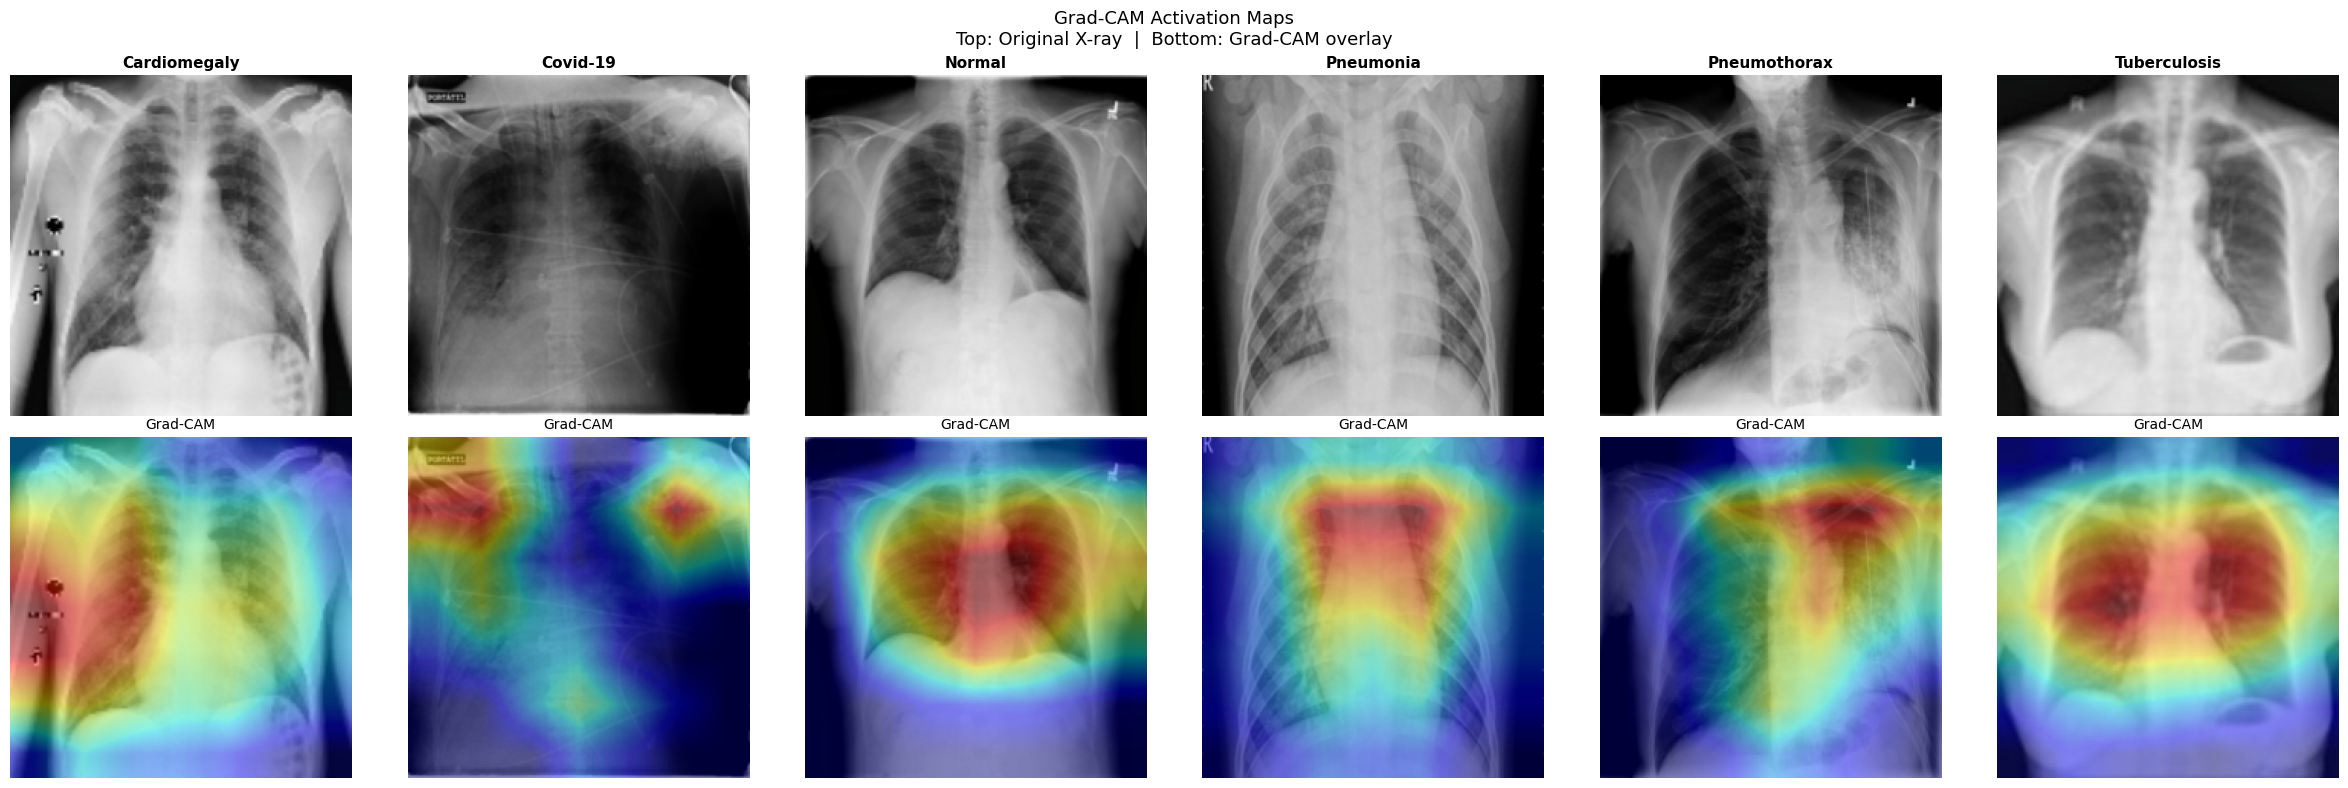

Saved: /content/drive/MyDrive/CNN_GNN_Results/gradcam.png


In [ ]:
# ── Grad-CAM ─────────────────────────────────────────────────
# Fixed for PyTorch 2.x + BatchNorm with single-image inference:
#   - Never call .squeeze() on activations/gradients
#   - Index [0] explicitly to strip batch dim
#   - Use torch.enable_grad() so backward works inside eval mode
#   - register_full_backward_hook (not deprecated register_backward_hook)

class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.activations = None   # [1, C, H, W]
        self.gradients   = None   # [1, C, H, W]
        self._fh = model.encoder[-1].register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        self._bh = model.encoder[-1].register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0]))

    def remove(self):
        self._fh.remove(); self._bh.remove()

    def generate(self, img_t, class_idx):
        """img_t: [3,H,W] CPU tensor — single image, no batch dim."""
        self.model.eval()
        inp = img_t.unsqueeze(0).to(device)   # [1,3,H,W]
        with torch.enable_grad():
            inp    = inp.requires_grad_(True)
            logits = self.model(inp)           # [1,C]
            self.model.zero_grad()
            logits[0, class_idx].backward()

        acts    = self.activations[0]          # [C, H, W]  — strip batch dim
        grads   = self.gradients[0]            # [C, H, W]
        weights = grads.mean(dim=[1, 2], keepdim=True)   # [C,1,1]
        cam     = (weights * acts).sum(0)      # [H, W]
        cam     = F.relu(cam).cpu().numpy()
        cam    -= cam.min()
        if cam.max() > 0: cam /= cam.max()
        return cam


def make_gradcam_figure(model, dataset, save_path):
    mean = np.array([0.485,0.456,0.406])
    std  = np.array([0.229,0.224,0.225])
    gcam = GradCAM(model)

    # Collect one correctly-classified image per class
    examples = {}
    model.eval()
    for img_t, lbl in dataset:
        if len(examples) == NUM_CLASSES: break
        if lbl in examples: continue
        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(device)).argmax(1).item()
        if pred == lbl:
            examples[lbl] = img_t   # [3,H,W] on CPU

    print(f'Grad-CAM: found examples for classes {sorted(examples.keys())}')
    n = len(examples)
    if n == 0:
        print('ERROR: No correct predictions found. Check model.'); return

    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    if n == 1: axes = axes.reshape(2, 1)

    for col, cls_idx in enumerate(sorted(examples)):
        img_t = examples[cls_idx]
        cam   = gcam.generate(img_t, cls_idx)
        img_np = np.clip(img_t.permute(1,2,0).numpy()*std+mean, 0, 1)
        cam_up = np.array(
            Image.fromarray((cam*255).astype(np.uint8))
                 .resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)) / 255.0
        heatmap = plt.cm.jet(cam_up)[...,:3]
        overlay = np.clip(0.55*img_np + 0.45*heatmap, 0, 1)

        axes[0,col].imshow(img_np); axes[0,col].axis('off')
        axes[0,col].set_title(CLASS_NAMES[cls_idx], fontsize=11, fontweight='bold')
        axes[1,col].imshow(overlay); axes[1,col].axis('off')
        axes[1,col].set_title('Grad-CAM', fontsize=10)

    gcam.remove()   # clean up hooks
    plt.suptitle(
        'Grad-CAM Activation Maps\nTop: Original X-ray  |  Bottom: Grad-CAM overlay',
        fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()
    print(f'Saved: {save_path}')


make_gradcam_figure(proposed_model, test_ds, f'{RESULTS_DIR}/gradcam.png')


Optimal temperature T = 0.6051
  T > 1 → model overconfident (probabilities too sharp)
  T < 1 → model underconfident (probabilities too flat)


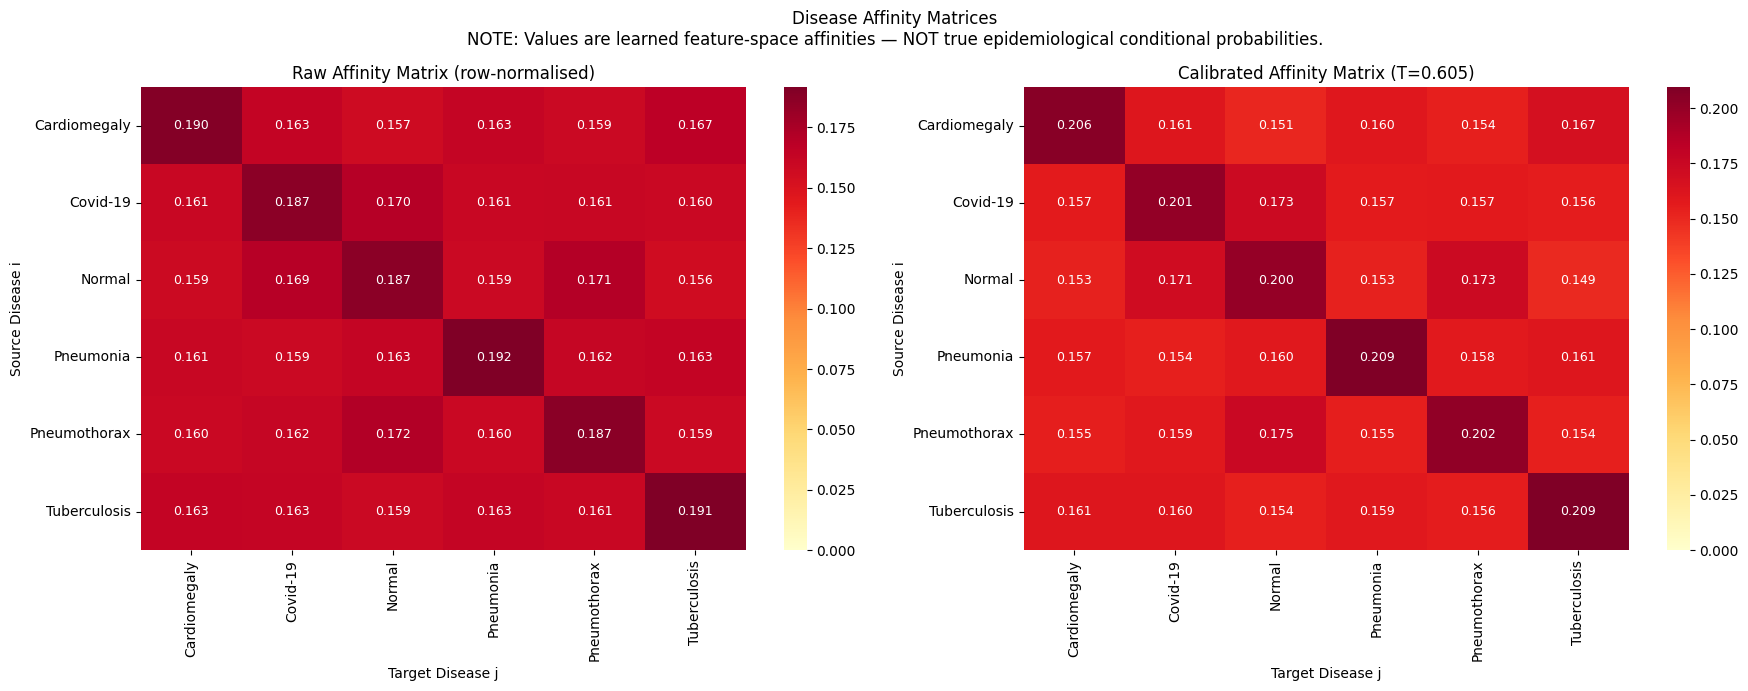


Calibrated Affinity Matrix (for paper Table 5):
              Cardiomegaly  Covid-19  Normal  Pneumonia  Pneumothorax  Tuberculosis
Cardiomegaly         0.206     0.161   0.151      0.160         0.154         0.167
Covid-19             0.157     0.201   0.173      0.157         0.157         0.156
Normal               0.153     0.171   0.200      0.153         0.173         0.149
Pneumonia            0.157     0.154   0.160      0.209         0.158         0.161
Pneumothorax         0.155     0.159   0.175      0.155         0.202         0.154
Tuberculosis         0.161     0.160   0.154      0.159         0.156         0.209
Saved cal_adj.npy, raw_adj.npy, T_val.json to Drive.


In [ ]:
# ── Temperature Calibration of Affinity Matrix ───────────────
# Reviewer #3: distinguish 'learned affinity' from 'true probability'.
# We learn T on the validation set, then rescale the affinity matrix.

# Step 1: collect validation logits
val_logits_list, val_tgts_list = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        val_logits_list.append(proposed_model(imgs.to(device)).cpu())
        val_tgts_list.append(lbls)
val_logits_all = torch.cat(val_logits_list)
val_tgts_all   = torch.cat(val_tgts_list)

# Step 2: optimise temperature T using LBFGS
T = nn.Parameter(torch.tensor(1.5))
opt_T = optim.LBFGS([T], lr=0.1, max_iter=200)
nll   = nn.CrossEntropyLoss()

def eval_T():
    opt_T.zero_grad()
    loss = nll(val_logits_all / T.clamp(min=0.01), val_tgts_all)
    loss.backward(); return loss

opt_T.step(eval_T)
T_val = T.item()
print(f'Optimal temperature T = {T_val:.4f}')
print(f'  T > 1 → model overconfident (probabilities too sharp)')
print(f'  T < 1 → model underconfident (probabilities too flat)')

# Step 3: apply T to the raw affinity matrix
raw_adj = proposed_model.gnn.get_relationship_matrix()   # [6,6] numpy
raw_t   = torch.tensor(raw_adj, dtype=torch.float32)
cal_adj = F.softmax(
    torch.log(raw_t.clamp(min=1e-8)) / T_val, dim=1).numpy()

# Step 4: plot both matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mat, title in zip(axes, [raw_adj, cal_adj],
        ['Raw Affinity Matrix (row-normalised)',
         f'Calibrated Affinity Matrix (T={T_val:.3f})']):
    sns.heatmap(mat, annot=True, fmt='.3f',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='YlOrRd', vmin=0, vmax=mat.max(), ax=ax,
                annot_kws={'size':9})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Target Disease j'); ax.set_ylabel('Source Disease i')
plt.suptitle(
    'Disease Affinity Matrices\n'
    'NOTE: Values are learned feature-space affinities — '
    'NOT true epidemiological conditional probabilities.', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/affinity_calibrated.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCalibrated Affinity Matrix (for paper Table 5):')
df_cal = pd.DataFrame(cal_adj, index=CLASS_NAMES, columns=CLASS_NAMES)
print(df_cal.round(3).to_string())

# Save for NB4
np.save(f'{RESULTS_DIR}/cal_adj.npy', cal_adj)
np.save(f'{RESULTS_DIR}/raw_adj.npy', raw_adj)
with open(f'{RESULTS_DIR}/T_val.json','w') as f:
    json.dump({'T_val': T_val}, f)
print(f'Saved cal_adj.npy, raw_adj.npy, T_val.json to Drive.')
